# Aufgaben: Generatives Lernen

### Aufgabe 2: Implementierung (optional, ggf. längerfristig)

*Implementieren Sie ein GAN mit PyTorch. Verwenden Sie dafür einen beliebigen bildlichen Datensatz, bspw. MNIST.*


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Sicherstellen, dass PyTorch die GPU verwenden kann, falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwende Gerät: {device}")


Verwende Gerät: cpu


In [3]:
# --- Hyperparameter ---
latent_dim = 100  # Dimension des Zufallsvektors (Rauschen) für den Generator
image_size = 64  # Zielgröße der Bilder (MNIST ist 28x28, wir skalieren)
num_channels = 1  # Anzahl der Farbkanäle (1 für Graustufenbilder wie MNIST)
batch_size = 128  # Anzahl der Samples pro Batch
num_epochs = 50  # Anzahl der Trainings-Epochen
lr_G = 0.0002  # Lernrate für den Generator
lr_D = 0.0002  # Lernrate für den Diskriminator
beta1 = 0.5  # Beta1 für Adam-Optimierer (DCGAN-Standard)
beta2 = 0.999  # Beta2 für Adam-Optimierer
ngpu = 1  # Anzahl der GPUs, falls verwendet

# --- Datenvorbereitung ---
# Transformationen: Skalierung auf image_size, Umwandlung in Tensor, Normalisierung auf [-1, 1]
transform = transforms.Compose(
    [
        transforms.Resize(image_size),  # Bilder auf Zielgröße skalieren
        transforms.ToTensor(),  # Bilder in PyTorch Tensor umwandeln (skaliert automatisch auf [0, 1])
        transforms.Normalize(
            (0.5,), (0.5,)
        ),  # Normalisiert auf [-1, 1] (Mittelwert 0.5, Std.abw. 0.5)
    ]
)

# Laden des Trainings-Datensatzes
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

# DataLoader für das Training
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

print(f"Anzahl der Trainingsbilder: {len(train_dataset)}")
print(f"Größe eines transformierten Bildes: {image_size}x{image_size} Pixel")


100%|██████████| 9.91M/9.91M [00:10<00:00, 912kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 247kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.28MB/s]

Anzahl der Trainingsbilder: 60000
Größe eines transformierten Bildes: 64x64 Pixel


### Generator definieren 

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_channels, image_size):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input ist Z, ein latenter Vektor der Größe latent_dim
            # Wir starten mit einem kleinen Feature Map, das wir upsamplen
            nn.ConvTranspose2d(latent_dim, image_size * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(image_size * 8),
            nn.ReLU(True),
            # Feature Map Größe: (image_size*8) x 4 x 4
            nn.ConvTranspose2d(image_size * 8, image_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size * 4),
            nn.ReLU(True),
            # Feature Map Größe: (image_size*4) x 8 x 8
            nn.ConvTranspose2d(image_size * 4, image_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size * 2),
            nn.ReLU(True),
            # Feature Map Größe: (image_size*2) x 16 x 16
            nn.ConvTranspose2d(image_size * 2, image_size, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size),
            nn.ReLU(True),
            # Feature Map Größe: (image_size) x 32 x 32 (für image_size=64, dies wäre 64x32x32, daher muss image_size hier den "Breiten"-Faktor darstellen)
            # -> Anpassen für image_size=64: Die letzte Schicht muss zum finalen Bild führen.
            # Wenn image_size = 64, dann ist image_size im Layer 64 (für die Anzahl der Features)
            # Das ist die Anzahl der Features. Die Dimensionen der Output-Bilder sind immer image_size x image_size.
            # Hier müsste ich die Architektur für 64x64 Bilder anpassen, oder die Variable `image_size` als
            # 'ngf' (number of generator filters) im DCGAN-Tutorial umbenennen.
            # Ich halte mich an das DCGAN-Tutorial: image_size hier bezieht sich auf "ngf" etc.
            # Der MNIST ist 28x28, ich skaliere ihn auf 64x64, also brauche ich genug Transpose Conv Layer.
            # Ein 64x64 Bild benötigt 4 Upsampling-Stufen von einem 4x4 Start.
            # Korrigierte Architektur für 64x64 Bilder (4 Upsampling-Stufen)
            nn.ConvTranspose2d(image_size, num_channels, 4, 2, 1, bias=False),
            nn.Tanh(),  # Tanh skaliert die Pixelwerte auf [-1, 1]
            # Output Größe: num_channels x 64 x 64
        )

    def forward(self, input):
        return self.main(input)


# Instanz des Generators
netG = Generator(latent_dim, image_size, image_size).to(
    device
)  # image_size hier als ngf im DCGAN-Tutorial
print("Generator Architektur:")
print(netG)


Generator Architektur:
Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)

### Diskriminator definieren 

In [5]:
class Discriminator(nn.Module):
    def __init__(self, num_channels, image_size):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input ist ein Bild (num_channels) x 64 x 64
            nn.Conv2d(num_channels, image_size, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Feature Map Größe: image_size x 32 x 32
            nn.Conv2d(image_size, image_size * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Feature Map Größe: image_size*2 x 16 x 16
            nn.Conv2d(image_size * 2, image_size * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Feature Map Größe: image_size*4 x 8 x 8
            nn.Conv2d(image_size * 4, image_size * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(image_size * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Feature Map Größe: image_size*8 x 4 x 4
            nn.Conv2d(image_size * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),  # Sigmoid für die binäre Klassifikation (real/fake)
            # Output Größe: 1x1x1
        )

    def forward(self, input):
        return self.main(input)


# Instanz des Diskriminators
netD = Discriminator(num_channels, image_size).to(
    device
)  # image_size hier als ndf im DCGAN-Tutorial
print("\nDiskriminator Architektur:")
print(netD)



Diskriminator Architektur:
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


### Verlustfunktion und Optimierer

In [6]:
# Verlustfunktion für das Training (Binary Cross-Entropy Loss)
criterion = nn.BCELoss()

# Labels für echtes (1) und gefälschtes (0) Training
real_label = 1.0
fake_label = 0.0

# Optimierer für G und D
optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, beta2))
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, beta2))


### Training des GANs

In [7]:
# Liste zur Speicherung von Trainingsstatistiken
img_list = []  # Zum Speichern von Beispielbildern, die vom Generator erstellt wurden
G_losses = []  # Generator-Verluste
D_losses = []  # Diskriminator-Verluste
iters = 0  # Iterationszähler

print("Starte GAN Training...")
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader, 0):
        # --- (1) Diskriminator trainieren: Maximiere log(D(x)) + log(1 - D(G(z))) ---

        # Trainiere mit realen Bildern
        netD.zero_grad()  # Setze Gradienten des Diskriminators zurück
        real_cpu = data[0].to(device)  # Echte Bilder
        b_size = real_cpu.size(0)
        label = torch.full(
            (b_size,), real_label, dtype=torch.float, device=device
        )  # Labels für reale Bilder (1)
        output = netD(real_cpu).view(-1)  # Diskriminator-Ausgabe für reale Bilder
        errD_real = criterion(output, label)  # Verlust für reale Bilder
        errD_real.backward()  # Backward-Pass
        D_x = (
            output.mean().item()
        )  # Durchschnittliche Ausgabe des Diskriminators für reale Bilder

        # Trainiere mit gefälschten Bildern
        noise = torch.randn(
            b_size, latent_dim, 1, 1, device=device
        )  # Zufallsrauschen für Generator
        fake = netG(noise)  # Generator erzeugt gefälschte Bilder
        label.fill_(fake_label)  # Labels für gefälschte Bilder (0)
        output = netD(
            fake.detach()
        ).view(
            -1
        )  # Diskriminator-Ausgabe für gefälschte Bilder (detach, damit G nicht aktualisiert wird)
        errD_fake = criterion(output, label)  # Verlust für gefälschte Bilder
        errD_fake.backward()  # Backward-Pass
        D_G_z1 = output.mean().item()  # Durchschnittliche Ausgabe des Diskriminators für gefälschte Bilder (bevor G trainiert wird)
        errD = errD_real + errD_fake  # Gesamtverlust des Diskriminators
        optimizerD.step()  # Diskriminator-Gewichte aktualisieren

        # --- (2) Generator trainieren: Maximiere log(D(G(z))) ---
        # (Wir wollen, dass der Diskriminator die vom Generator erzeugten Bilder als 'real' klassifiziert)
        netG.zero_grad()  # Setze Gradienten des Generators zurück
        label.fill_(
            real_label
        )  # Labels sind jetzt 'real' (1), um G zu trainieren, D zu täuschen
        output = netD(fake).view(
            -1
        )  # Diskriminator-Ausgabe für die neu generierten gefälschten Bilder
        errG = criterion(output, label)  # Verlust des Generators
        errG.backward()  # Backward-Pass
        D_G_z2 = output.mean().item()  # Durchschnittliche Ausgabe des Diskriminators für gefälschte Bilder (nach G-Training)
        optimizerG.step()  # Generator-Gewichte aktualisieren

        # --- Fortschritt ausgeben und Verluste speichern ---
        if i % 50 == 0:  # Ausgabe alle 50 Batches
            print(
                f"[{epoch + 1}/{num_epochs}][{i}/{len(train_loader)}]\t"
                f"Loss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\t"
                f"D(x): {D_x:.4f}\tD(G(z))_before_G: {D_G_z1:.4f}\tD(G(z))_after_G: {D_G_z2:.4f}"
            )

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Speichern der Generator-Ausgabe für Visualisierung
        if (iters % 500 == 0) or (
            (epoch == num_epochs - 1) and (i == len(train_loader) - 1)
        ):
            with torch.no_grad():
                # Erzeuge fixe Rauschen, um den Fortschritt der Generierung zu sehen
                fixed_noise = torch.randn(
                    64, latent_dim, 1, 1, device=device
                )  # 64 feste Rauschvektoren
                fake_images_for_viz = netG(fixed_noise).detach().cpu()
            img_list.append(
                make_grid(fake_images_for_viz, padding=2, normalize=True)
            )  # Speichere Grid der Bilder

        iters += 1

print("GAN Training beendet.")


Starte GAN Training...


RuntimeError: Given groups=1, weight of size [64, 1, 4, 4], expected input[128, 64, 64, 64] to have 1 channels, but got 64 channels instead

### Visualisierung

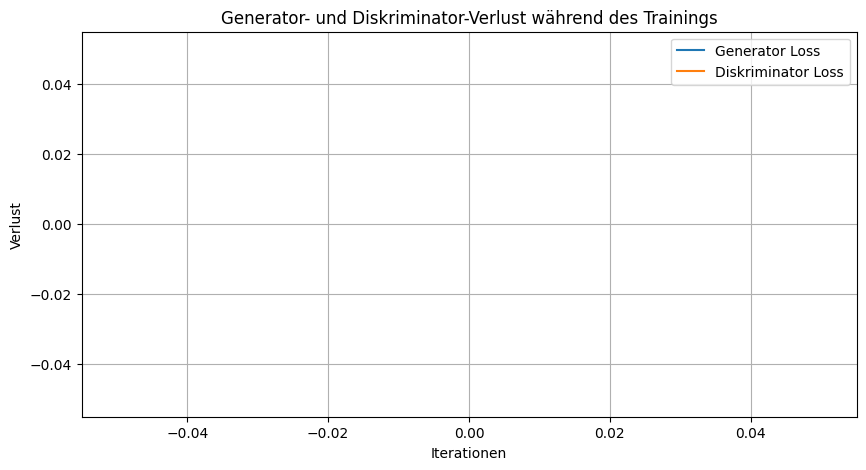

IndexError: list index out of range

In [8]:
# a) Plot der Generator- und Diskriminator-Verluste
plt.figure(figsize=(10, 5))
plt.title("Generator- und Diskriminator-Verlust während des Trainings")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Diskriminator Loss")
plt.xlabel("Iterationen")
plt.ylabel("Verlust")
plt.legend()
plt.grid(True)
plt.show()

# b) Visualisierung der generierten Bilder
# Hole das letzte erzeugte Bild-Grid aus der Liste
final_generated_grid = img_list[-1]

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generierte Bilder nach Training")
# make_grid normalisiert bereits, also imshow zeigt es richtig an
plt.imshow(np.transpose(final_generated_grid, (1, 2, 0)))
plt.show()

# Optional: Vergleich mit echten Bildern
# Hole einen Batch echter Bilder vom DataLoader
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Echte Trainingsbilder")
plt.imshow(
    np.transpose(
        make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),
        (1, 2, 0),
    )
)
plt.show()
